# **OcuDetect AI / FundusGuard AI**

model p1 using ResNet-50

In [ ]:
!pip install kaggle

In [ ]:
from google.colab import files
files.upload()

{}

In [ ]:
!mkdir -p ~/.kaggle
!cp /content/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# **Collect Dataset**

In [ ]:
!kaggle datasets download -d arnavjain1/glaucoma-datasets

!unzip glaucoma-datasets.zip -d glaucoma_dataset

Streaming output truncated to the last 5000 lines.
  inflating: glaucoma_dataset/REFUGE/test/Masks_Cropped/T0207.png  
  inflating: glaucoma_dataset/REFUGE/test/Masks_Cropped/T0208.png  
  inflating: glaucoma_dataset/REFUGE/test/Masks_Cropped/T0209.png  
  inflating: glaucoma_dataset/REFUGE/test/Masks_Cropped/T0210.png  
  inflating: glaucoma_dataset/REFUGE/test/Masks_Cropped/T0211.png  
  inflating: glaucoma_dataset/REFUGE/test/Masks_Cropped/T0212.png  
  inflating: glaucoma_dataset/REFUGE/test/Masks_Cropped/T0213.png  
  inflating: glaucoma_dataset/REFUGE/test/Masks_Cropped/T0214.png  
  inflating: glaucoma_dataset/REFUGE/test/Masks_Cropped/T0215.png  
  inflating: glaucoma_dataset/REFUGE/test/Masks_Cropped/T0216.png  
  inflating: glaucoma_dataset/REFUGE/test/Masks_Cropped/T0217.png  
  inflating: glaucoma_dataset/REFUGE/test/Masks_Cropped/T0218.png  
  inflating: glaucoma_dataset/REFUGE/test/Masks_Cropped/T0219.png  
  inflating: glaucoma_dataset/REFUGE/test/Masks_Cropped/T0220.png

**File structure:**

+ glaucoma_dataset
  + G1020
    + Images
      - image_0.jpg
      - image_0.json
      - image_1.jpg
      - image_1.json
      
      .....
    + Images_Cropped
    + Image_Square
    + Masks
    + Masks_Cropped
    + Mask_Square
    + NerveRemoved_Images
    - G1020.CSV
  + ORIGA
    + Images
        - image_0.jpg
        - image_0.json
        - image_1.jpg
        - image_1.json
        
        .....
    + Images_Cropped
    + Image_Square
    + Masks
    + Masks_Cropped
    + Mask_Square
    + Semi-automatic-annotations
    - OrigaList.CSV
  + REFUGE
  + MODELS
    - refug_clf.pkl
    - refuge_segmentation.pth



# **Preprocessing Time**

In [ ]:
import os
import shutil
import pandas as pd
from sklearn.model_selection import train_test_split
from collections import Counter
from PIL import Image

In [ ]:
SOURCE_PATH = "glaucoma_dataset"
DEST_PATH = "dataset"
ROI_DEST_PATH = "dataset/roi"

classes = ["glaucoma", "normal"]
splits = ["train", "val", "test"]

In [ ]:
# consider the RGB image for dataset
def convert_to_jpg(src_path, dst_path):
    img = Image.open(src_path).convert("RGB")
    dst_path = os.path.splitext(dst_path)[0] + ".jpg"
    img.save(dst_path, "JPEG", quality=95)

In [ ]:
def process_dataset(source_folder, csv_file, output_root=DEST_PATH, roi_output_root=ROI_DEST_PATH):

    csv_path = os.path.join(source_folder, csv_file)
    df = pd.read_csv(csv_path)

    print("\nProcessing:", source_folder)

    if "G1020" in source_folder:
        image_col = "imageID"
        label_col = "binaryLabels"
        images_folder = os.path.join(source_folder, "Images")

        roi_folders = [
            os.path.join(source_folder, "Images_Cropped"),
            os.path.join(source_folder, "Images_Cropped", "img")
        ]

    elif "ORIGA" in source_folder:
        image_col = "Filename"
        label_col = "Glaucoma"
        images_folder = os.path.join(source_folder, "Images_Cropped")

        roi_folders = [
            os.path.join(source_folder, "Images_Cropped")
        ]

    else:
        raise ValueError("Unknown dataset")

    images = df[image_col].astype(str).str.strip().values
    labels = df[label_col].astype(int).values

    # I am Separate small classes (less than 2 samples)
    class_counts = Counter(labels)
    print("Class Distribution:", class_counts)

    valid_images = []
    valid_labels = []
    roi_paths = []

    # for img, lbl in zip(images, labels):
    #     img_path = os.path.join(images_folder, img)

    #     if os.path.exists(img_path):
    #         valid_images.append(img_path)
    #         valid_labels.append(lbl)

    extensions = [".jpg", ".jpeg", ".png", ".bmp"]

    for img, lbl in zip(images, labels):
        base_name = os.path.splitext(img)[0]
        full_path = None
        for ext in extensions:
            p = os.path.join(images_folder, base_name + ext)
            if os.path.exists(p):
                full_path = p
                break

        if full_path is None:
            print("Missing full:", img)
            continue

        roi_path = None
        for roi_folder in roi_folders:
            for ext in extensions:
                p = os.path.join(roi_folder, base_name + ext)
                if os.path.exists(p):
                    roi_path = p
                    break
            if roi_path:
                break

        valid_images.append(full_path)
        valid_labels.append(lbl)
        roi_paths.append(roi_path)  # may be None

    print("Valid images found:", len(valid_images))

    class_counts = Counter(valid_labels)
    small_classes = [cls for cls, count in class_counts.items() if count < 2]

    print("Small classes:", small_classes)

    train_imgs, train_lbls = [], []
    valid_imgs, valid_lbls = [], []

    for img, lbl in zip(valid_images, valid_labels):
        if lbl in small_classes:
            train_imgs.append(img)
            train_lbls.append(lbl)
        else:
            valid_imgs.append(img)
            valid_lbls.append(lbl)

    # Train (60%)
    X_train, X_temp, y_train, y_temp, roi_train, roi_temp = train_test_split(
        valid_images, valid_labels, roi_paths,
        test_size=0.4,
        stratify=valid_labels,
        random_state=42
    )

    # Validation (10%) and Test (30%)
    X_val, X_test, y_val, y_test, roi_val, roi_test = train_test_split(
        X_temp, y_temp, roi_temp,
        test_size=0.75,
        stratify=y_temp,
        random_state=42
    )

    # At last add small class samples fully to the train
    X_train += train_imgs
    y_train += train_lbls

    print(f"Train: {len(X_train)}")
    print(f"Validation: {len(X_val)}")
    print(f"Test: {len(X_test)}")

    for root in [output_root, roi_output_root]:
        for split in splits:
            for cls in classes:
                os.makedirs(os.path.join(root, split, cls), exist_ok=True)

    # just doing copy past samples (not touch the original)
    def copy_files(images, labels, roi_list, split_name):
        for img, lbl, roi_img in zip(images, labels, roi_list):
            class_name = "glaucoma" if lbl == 1 else "normal"

            dst = os.path.join(
                output_root,
                split_name,
                class_name,
                os.path.basename(img)
            )

            ext = os.path.splitext(img)[1].lower()

            if ext in [".jpg", ".jpeg"]:
                shutil.copy(img, dst)
            elif ext in [".png", ".bmp", ".tiff"]: #changing it to RGB
                convert_to_jpg(img, dst)

            if roi_img:
                dst_roi = os.path.join(
                    roi_output_root,
                    split_name,
                    class_name,
                    os.path.basename(img)
                )
                if ext in [".jpg", ".jpeg"]:
                  shutil.copy(img, dst_roi)
                elif ext in [".png", ".bmp", ".tiff"]: #changing it to RGB
                  convert_to_jpg(img, dst_roi)

    copy_files(X_train, y_train, roi_train, "train")
    copy_files(X_val, y_val, roi_val, "val")
    copy_files(X_test, y_test, roi_test, "test")

    print("Dataset prepared successfully!")

In [ ]:
# process_dataset(
#     os.path.join(SOURCE_PATH, "G1020"),
#     "G1020.csv",
#     "Images_Cropped"
# )

# process_dataset(
#     os.path.join(SOURCE_PATH, "ORIGA"),
#     "OrigaList.csv",
#     "origa_info.csv"
#     "Images_Cropped"
# )

# print("Dataset split into Train, Test, Val successfully!")

process_dataset(
    os.path.join(SOURCE_PATH, "G1020"),
    "G1020.csv"
)

process_dataset(
    os.path.join(SOURCE_PATH, "ORIGA"),
    "OrigaList.csv"
)

print("Dataset split into Train, Test, Val successfully!")


Processing: glaucoma_dataset/G1020
Class Distribution: Counter({np.int64(0): 724, np.int64(1): 296})
Valid images found: 1020
Small classes: []
Train: 612
Validation: 102
Test: 306
Dataset prepared successfully!

Processing: glaucoma_dataset/ORIGA
Class Distribution: Counter({np.int64(0): 482, np.int64(1): 168})
Valid images found: 650
Small classes: []
Train: 390
Validation: 65
Test: 195
Dataset prepared successfully!
Dataset split into Train, Test, Val successfully!


Not need, so i delete this:
  + Images_Cropped/
  + origa_info.csvImages_Cropped/


In [ ]:
shutil.rmtree("Images_Cropped", ignore_errors=True)
shutil.rmtree("origa_info.csvImages_Cropped", ignore_errors=True)

**Download the Preprocessed Dataset**

In [ ]:
from google.colab import files

shutil.make_archive("dataset", 'zip', "dataset")

#files.download("dataset.zip")

'/content/dataset.zip'

# **Data Augmentaion for Variation**

In [ ]:
import os
import random
from PIL import Image, ImageEnhance, ImageOps
import numpy as np

In [ ]:
# augment iin only train/ folder
DATASET_PATH = "dataset/train"
ROI_PATH = "dataset/roi/train"

In [ ]:
def rotate(img):
    return img.rotate(random.choice([90, 180, 270]))

def flip(img):
    if random.random() > 0.5:
        return ImageOps.mirror(img)   # horizontal flip
    else:
        return ImageOps.flip(img)     # vertical flip

def brightness(img):
    enhancer = ImageEnhance.Brightness(img)
    return enhancer.enhance(random.uniform(0.7, 1.3))

def contrast(img):
    enhancer = ImageEnhance.Contrast(img)
    return enhancer.enhance(random.uniform(0.7, 1.3))

def color(img):
    enhancer = ImageEnhance.Color(img)
    return enhancer.enhance(random.uniform(0.7, 1.3))

def add_noise(img):
    arr = np.array(img)
    noise = np.random.randint(0, 30, arr.shape, dtype='uint8')
    arr = np.clip(arr + noise, 0, 255)
    return Image.fromarray(arr)

augmentations = [rotate, flip, brightness, contrast, color, add_noise]


In [ ]:
# def augment_dataset():
#     print("Augmenting start...")
#     for class_name in ["glaucoma", "normal"]:
#         class_path = os.path.join(DATASET_PATH, class_name)
#         print(f"Work on: {class_path}")

#         for img_name in os.listdir(class_path):
#             img_path = os.path.join(class_path, img_name)

#             if not img_name.lower().endswith(".jpg"):
#                 continue

#             img = Image.open(img_path).convert("RGB")

#             # i create 3 augmented copies per image
#             for i in range(3):
#                 aug_img = img.copy()

#                 # apply any 2 random augmentations
#                 for aug in random.sample(augmentations, 2):
#                     aug_img = aug(aug_img)

#                 new_name = f"aug_{i}_{img_name}"
#                 save_path = os.path.join(class_path, new_name)

#                 aug_img.save(save_path, "JPEG", quality=95)

#     print("Augmentation completed successfully!")

# augment_dataset()

## Class Balancing via Targeted Augmentation
def augment_dataset():
    print("Augmenting start...")
    for class_name in ["glaucoma", "normal"]:
        class_path = os.path.join(DATASET_PATH, class_name)
        roi_class_path = os.path.join(ROI_PATH, class_name)

        print(f"\nWork on: {class_path}\n")

        if class_name == "glaucoma":
            num_copies = 3   # MORE copies
        else:
            num_copies = 1   # LESS copies

        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            roi_img_path = os.path.join(roi_class_path, img_name)

            print(f"aug: {img_path}")

            if not img_name.lower().endswith(".jpg"):
                continue

            if not os.path.exists(roi_img_path):
                print("ROI missing:", img_name)
                continue

            img = Image.open(img_path).convert("RGB")
            roi_img = Image.open(roi_img_path).convert("RGB")

            for i in range(num_copies):
                aug_img = img.copy()
                aug_roi = roi_img.copy()

                # SAME augmentations applied to both
                chosen_augs = random.sample(augmentations, 2)

                # apply any 2 random augmentations
                for aug in chosen_augs:
                    aug_img = aug(aug_img)
                    aug_roi = aug(aug_roi)

                new_name = f"aug_{i}_{img_name}"

                save_full = os.path.join(class_path, new_name)
                save_roi = os.path.join(roi_class_path, new_name)

                aug_img.save(save_full, "JPEG", quality=95)
                aug_roi.save(save_roi, "JPEG", quality=95)

    print("Augmentation completed successfully!")

augment_dataset()

Augmenting start...

Work on: dataset/train/glaucoma

aug: dataset/train/glaucoma/image_2047.jpg
aug: dataset/train/glaucoma/433.jpg
aug: dataset/train/glaucoma/image_1032.jpg
aug: dataset/train/glaucoma/image_1271.jpg
aug: dataset/train/glaucoma/640.jpg
aug: dataset/train/glaucoma/image_19.jpg
aug: dataset/train/glaucoma/600.jpg
aug: dataset/train/glaucoma/image_2731.jpg
aug: dataset/train/glaucoma/304.jpg
aug: dataset/train/glaucoma/432.jpg
aug: dataset/train/glaucoma/image_1899.jpg
aug: dataset/train/glaucoma/image_201.jpg
aug: dataset/train/glaucoma/image_1319.jpg
aug: dataset/train/glaucoma/636.jpg
aug: dataset/train/glaucoma/image_941.jpg
aug: dataset/train/glaucoma/180.jpg
aug: dataset/train/glaucoma/395.jpg
aug: dataset/train/glaucoma/image_1002.jpg
aug: dataset/train/glaucoma/381.jpg
aug: dataset/train/glaucoma/image_2201.jpg
aug: dataset/train/glaucoma/110.jpg
aug: dataset/train/glaucoma/348.jpg
aug: dataset/train/glaucoma/340.jpg
aug: dataset/train/glaucoma/image_2655.jpg
au

# **Data Distribution**

In [ ]:
import os
import matplotlib.pyplot as plt

In [ ]:
DATASET_PATH = "dataset"

splits = ["train", "val", "test"]
classes = ["glaucoma", "normal"]

labels = []
counts = []

for split in splits:
    for cls in classes:
        path = os.path.join(DATASET_PATH, split, cls)

        num_images = len([
            f for f in os.listdir(path)
            if f.lower().endswith(".jpg")
        ])

        labels.append(f"{split}/{cls}")
        counts.append(num_images)

print(f"labels: {labels},\nCounts: {counts}")

short_labels = ["Tr-G", "Tr-N", "Va-G", "Va-N", "Te-G", "Te-N"]


labels: ['train/glaucoma', 'train/normal', 'val/glaucoma', 'val/normal', 'test/glaucoma', 'test/normal'],
Counts: [1116, 1446, 47, 120, 138, 363]


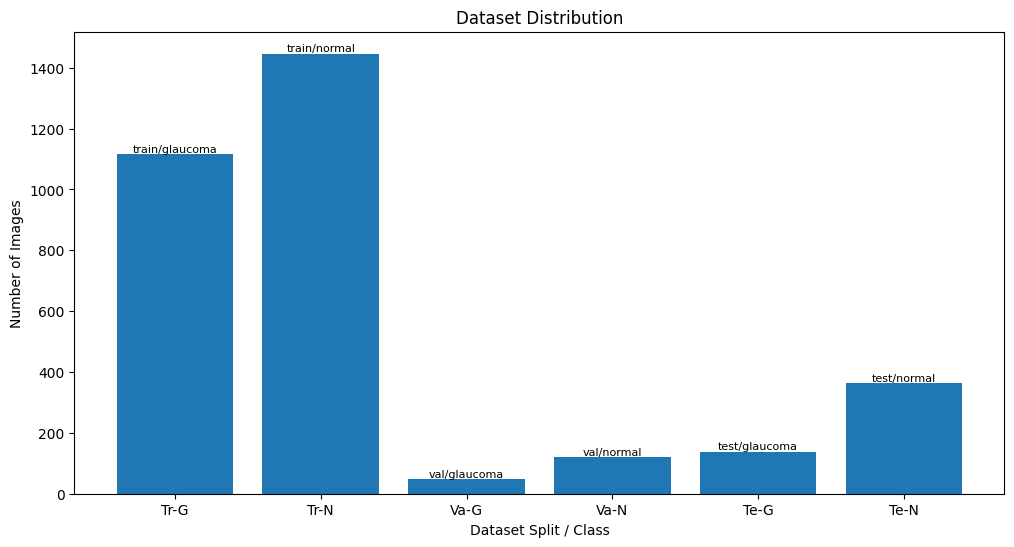

In [ ]:
plt.figure(figsize=(12,6))

plt.bar(short_labels, counts)

plt.xlabel("Dataset Split / Class")
plt.ylabel("Number of Images")
plt.title("Dataset Distribution")

for i, txt in enumerate(labels):
    plt.text(i, counts[i], txt, ha='center', va='bottom', fontsize=8)

plt.show()

**Download the Augmentated Dataset**

In [ ]:
from google.colab import files

shutil.make_archive("train", 'zip', "dataset/train")

files.download("train.zip")

KeyboardInterrupt: 

In [ ]:
shutil.make_archive("test", 'zip', "dataset/test")

files.download("test.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
shutil.make_archive("val", 'zip', "dataset/val")

files.download("val.zip")

'/content/val.zip'

In [ ]:
shutil.make_archive("roi", 'zip', "dataset/roi")

files.download("roi.zip")

'/content/roi.zip'

In [ ]:
!du -sh roi.zip

2.9G	roi.zip


**Prune Un-necessary files from temp state**

In [ ]:
!rm train.zip
!rm test.zip
!rm val.zip
!rm roi.zip

# **Define the ResNet50 Architecture**

# Why ResNet-50 Is Good for My Project

I am using:
* Fundus eye images
* Binary classification (glaucoma vs normal)
* Small/medium dataset

ResNet-50 works well because:

1. Pretrained features already know edges, textures, shapes

2. Deep enough to capture optic disc patterns

3. Transfer learning works well for medical images as my past expriments

So using **ImageNet pretrained ResNet‑50** is a good choice for this.

# Architecture

The model structure looks like this:

```
Input Image (224*224*3)
      ↓
Initial Convolution Layer
      ↓
Max Pooling
      ↓
Residual Block Group 1
      ↓
Residual Block Group 2
      ↓
Residual Block Group 3
      ↓
Residual Block Group 4
      ↓
Global Average Pooling
      ↓
Fully Connected Layer
      ↓
Softmax / Sigmoid Output
```

binary output project:

```
Output = Glaucoma / Normal as 1 / 0
```



## Input Layer

Input image size:

```
225 * 224 * 3
```

3 channels = RGB.

Your fundus image is resized to this.


# Residual Block Groups

ResNet-50 has 4 main stages.

| Stage   | Output Size | Blocks   | What it learns      |
| ------- | ----------- | -------- | ------------------- |
| Stage 1 | 56*56       | 3 blocks | edges, colors       |
| Stage 2 | 28*28       | 4 blocks | shapes, vessels     |
| Stage 3 | 14*14       | 6 blocks | optic disc patterns |
| Stage 4 | 7*7         | 3 blocks | glaucoma indicators |

Total = 16 residual blocks

Each block has 3 convolution layers.
- 49 convolution layers
- 1 fully connected layer


# **Deploy ResNet-50**

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from torchsummary import summary

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device) #ensure i am in colab

Using device: cuda


In [ ]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(20),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
DATASET_PATH = "dataset"

train_dataset = datasets.ImageFolder(
    os.path.join(DATASET_PATH, "train"),
    transform=train_transforms
)

val_dataset = datasets.ImageFolder(
    os.path.join(DATASET_PATH, "val"),
    transform=val_test_transforms
)

test_dataset = datasets.ImageFolder(
    os.path.join(DATASET_PATH, "test"),
    transform=val_test_transforms
)

In [ ]:
class_names = train_dataset.classes
print("Classes:", class_names) # i am expecting ['normal', 'glaucoma'] only

Classes: ['glaucoma', 'normal']


In [ ]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

train_labels = [label for _, label in train_dataset]

# adding class weights, because my dataset is not balanced
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

print("Class Weights:", class_weights)

Class Weights: tensor([1.1478, 0.8859], device='cuda:0')


**Load the ResNet-50 from torch directly**

In [ ]:
model = models.resnet50(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 161MB/s]


In [ ]:
# Freeze early layers for transfer learning

for param in model.parameters():
    param.requires_grad = False

# Unfreeze Layer4
for param in model.layer4.parameters():
    param.requires_grad = True

We know that ResNet50 output = 1000 classes.

but i change it to 2 classes (glaucoma / normal).

In [ ]:
num_features = model.fc.in_features

model.fc = nn.Sequential(
    nn.Linear(num_features, 256),
    nn.ReLU(),
    nn.Dropout(0.7), #0.5 to 0.7 for not remember, pattern find
    nn.Linear(256, 2)
)

In [ ]:
model = model.to(device)

In [ ]:
print("\nModel Architecture Summary:\n")

summary(model, (3, 224, 224))


Model Architecture Summary:

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]           4,096
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
           Conv2d-11          [-1, 256, 56, 56]          16,384
      BatchNorm2d-12          [-1, 256, 56, 56]             512
           Conv2d-13          [-1, 256, 56, 56]          16,384
      Bat

In [ ]:
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.0001,
    weight_decay=1e-4   # i add here L2 regularization for overcome the underfitting of my model
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.3,
    patience=3,
    # verbose=True
)

In [ ]:
EPOCHS = 20

In [ ]:
# i need this for later to make graphs and matrix
train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

best_val_loss = float('inf')
patience = 5
counter = 0

# **Training Phase**

In [ ]:
print("Training start...\n")

for epoch in range(EPOCHS):
    print(f"Epoch: {epoch+1} running..\n")
    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    # Validation
    model.eval()

    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss = val_loss / len(val_loader)
    val_acc = correct / total

    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS}", end=" ")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}", end=" | ")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}", end="\n\n")
    scheduler.step(val_loss)

    # (Early Stopping + Best Model Saving) for reduce overfitting if
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0

        model_path = f"gla_p1_{int(val_acc * 100)}.pth"
        torch.save(model.state_dict(), model_path)
        print(f"Best model saved: {model_path}\n")
    else:
        counter += 1
        if counter >= patience:
            print("\n>> Early stopping triggered\n")
            break

Training start...

Epoch: 1 running..

Epoch 1/20 Train Loss: 0.5198 | Train Acc: 0.7256 | Val Loss: 0.6647 | Val Acc: 0.7365

Epoch: 2 running..

Epoch 2/20 Train Loss: 0.4820 | Train Acc: 0.7646 | Val Loss: 0.7555 | Val Acc: 0.6467

Epoch: 3 running..

Epoch 3/20 Train Loss: 0.4383 | Train Acc: 0.8021 | Val Loss: 0.8547 | Val Acc: 0.5928

Epoch: 4 running..

Epoch 4/20 Train Loss: 0.4387 | Train Acc: 0.7982 | Val Loss: 0.7532 | Val Acc: 0.6886

Epoch: 5 running..

Epoch 5/20 Train Loss: 0.3566 | Train Acc: 0.8489 | Val Loss: 0.7441 | Val Acc: 0.7305


>> Early stopping triggered



# **Testing Phase**

In [ ]:
model.eval()

all_preds = []
all_labels = []

print("Testing start..\n\n")
with torch.no_grad():

    for images, labels in test_loader:
        print(f"Testing for {labels}")

        images = images.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

Testing start..


Testing for tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0])
Testing for tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0])
Testing for tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0])
Testing for tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0])
Testing for tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1])
Testing for tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1])
Testing for tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1])
Testing for tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1

# **Save Model**

In [44]:
torch.save(model.state_dict(), "gla_p1_73.pth")

In [45]:
!du -sh gla_p1_73.pth

92M	gla_p1_73.pth


# **Model Training Graph**

In [46]:
train_losses.append(train_loss)
val_losses.append(val_loss)

train_accuracies.append(train_acc)
val_accuracies.append(val_acc)

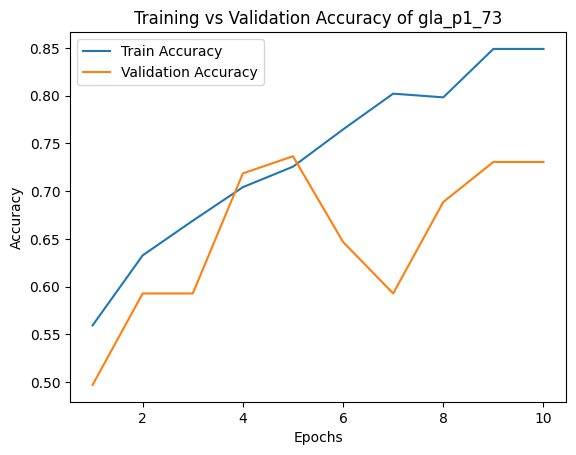

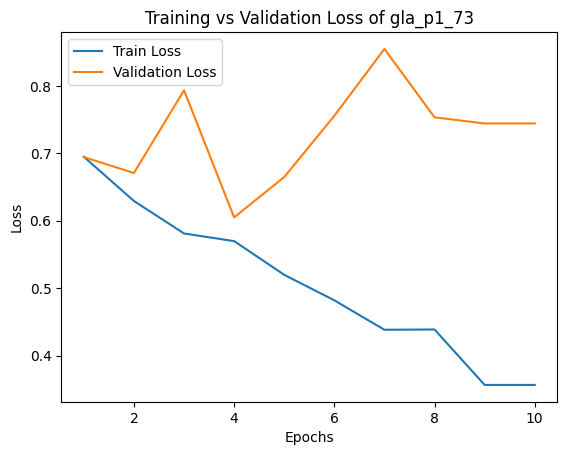

In [47]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(train_losses) + 1)

plt.figure()
plt.plot(epochs_range, train_accuracies, label='Train Accuracy')
plt.plot(epochs_range, val_accuracies, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy of gla_p1_73')
plt.legend()
plt.show()

plt.figure()
plt.plot(epochs_range, train_losses, label='Train Loss')
plt.plot(epochs_range, val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss of gla_p1_73')
plt.legend()
plt.show()
